Importar as bibliotecas necessárias

In [320]:
import timeit # Para medir o tempo de execução
import optuna # Para otimização de hiperparâmetros
start_time = timeit.default_timer() # Marcar o início do tempo
import torch
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
import numpy as np
from torchvision.utils import save_image
import matplotlib.pyplot as plt
# Definir o dispositivo (cuda se disponível, caso contrário CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
from scipy.stats import wasserstein_distance

import mplhep as hep
plt.style.use("default")
plt.style.use(hep.style.CMS)
plt.rcParams['font.size'] = 12 

cuda


In [321]:
def mass_func(data):
    data = torch.transpose(data, 0, 1)
    
    px = data[0] + data[1]
    py = data[2] + data[3]
    pz = data[4] + data[5]
    E = data[6] + data[7]

    m2 = E**2 - px**2 - py**2 - pz**2
    #m  = torch.sqrt(torch.clamp(m2, min=0.0))
    return m2

O próximo passo é carregar os dados de entrada. Os dados utilizados são valores de momento transversal dos píons e dos káons, partículas filha do méson D0. Inicialmente, os dados se encontram em um .txt, e devem ser transformados em um tensor no PyTorch. Além disso, os dados são normalizados para aumentar a estabilidade do treino e divididos em set de treino, validação e teste.

In [ ]:
# Carregar os dados de entrada
data = np.loadtxt("../Skims/data_D0_daughtersPx_Py_Pz_E_trk1_trk2.txt")
#D0_data = np.loadtxt("data_D0_daughtersPx_Py_Pz_E_D0.txt")

tensor_data_denormalized = torch.tensor(data, dtype=torch.float32, device=device)
#D0_data = torch.tensor(D0_data, dtype=torch.float32, device=device)

nVar = tensor_data_denormalized.shape[1]
mass_D0 = 1.8648

def normalize(x):
    return (x - means) / (stds + 1e-8)

def denormalize(x):
    if isinstance(x, np.ndarray):
        return x * (stds.numpy() + 1e-8) + means.numpy()
    return x * (stds + 1e-8) + means

print(f"Shape do tensor: {tensor_data_denormalized.shape}")
print(f"Raw {tensor_data_denormalized.size()}, {type(tensor_data_denormalized)}")
print(f"Dados do crus: {tensor_data_denormalized}")
print(f"Número de variáveis de entrada: {nVar}")

# Divisão dos dados em treino, validação e teste
nTotal = tensor_data_denormalized.size(0)
nTrain = int(0.6 * nTotal)
nVal = int(0.2 * nTotal)
nTest = nTotal - nTrain - nVal
print(f"nTrain: {nTrain}, nVal: {nVal}, nTest: {nTest}")

x_train_raw = tensor_data_denormalized[:nTrain]
x_val_raw   = tensor_data_denormalized[nTrain:nTrain + nVal]
x_test_raw  = tensor_data_denormalized[nTrain + nVal:]

# Estatísticas APENAS do train set
means = x_train_raw.mean(dim=0)
stds  = x_train_raw.std(dim=0)


tensor_data = normalize(tensor_data_denormalized)
# Normalizar cada split separadamente
x_train = normalize(x_train_raw)
x_val   = normalize(x_val_raw)
x_test  = normalize(x_test_raw)
tensor_data = normalize(tensor_data_denormalized)

print(f"x_train: {x_train.size()}, x_val: {x_val.size()}, x_test: {x_test.size()}")

# DataLoaders
batch_size = 64
trainloader = DataLoader(x_train, shuffle=True,  batch_size=batch_size)
valloader   = DataLoader(x_val,   shuffle=False, batch_size=batch_size)
testloader  = DataLoader(x_test,  shuffle=False, batch_size=batch_size)


x_train_phys = x_train_raw
c_train = torch.stack([
    x_train_phys[:, 0] + x_train_phys[:, 1],
    x_train_phys[:, 2] + x_train_phys[:, 3],
    x_train_phys[:, 4] + x_train_phys[:, 5],
    x_train_phys[:, 6] + x_train_phys[:, 7],
], dim=1)
c_means = c_train.mean(dim=0)
c_stds  = c_train.std(dim=0)
cVar = c_train.shape[1]

Shape do tensor: torch.Size([20000, 8])
Raw torch.Size([20000, 8]), <class 'torch.Tensor'>
Dados do crus: tensor([[ -0.1366,   2.0796,  -0.5123,  ...,  -2.2954,   0.7437,   3.7436],
        [ -1.7234,   0.1727,  -1.7169,  ...,   1.3204,   3.6637,   2.0659],
        [  1.5444,   1.7190,   0.1174,  ..., -10.7713,   4.3586,  10.9472],
        ...,
        [ -0.2093,   0.8172,  -2.9004,  ...,   0.9550,   3.3812,   1.3934],
        [ -0.6546,  -1.0264,  -0.0698,  ...,   0.2606,   0.9285,   2.1903],
        [  1.4160,   0.2751,   2.3829,  ...,  -0.0613,   5.6575,   0.6417]],
       device='cuda:0')
Número de variáveis de entrada: 8
nTrain: 12000, nVal: 4000, nTest: 4000
x_train: torch.Size([12000, 8]), x_val: torch.Size([4000, 8]), x_test: torch.Size([4000, 8])


In [323]:
class PlanarFlow(nn.Module):
    def __init__(self, z_dim):
        super().__init__()
        self.w = nn.Parameter(torch.randn(z_dim))
        self.u = nn.Parameter(torch.randn(z_dim))
        self.b = nn.Parameter(torch.zeros(1))

    def forward(self, z):
        wu = (self.w @ self.u)
        u_hat = self.u + (torch.log(1 + torch.exp(wu)) - 1 - wu) * self.w / (self.w @ self.w)
        
        lin = z @ self.w + self.b          # (N,)
        h = torch.tanh(lin)
        z_new = z + u_hat * h.unsqueeze(1) # (N, z_dim)
        
        # log det jacobiano
        psi = (1 - h**2).unsqueeze(1) * self.w  # (N, z_dim)
        log_det = torch.log((1 + psi @ u_hat).abs() + 1e-8)
        return z_new, log_det

Construção do VAE. A arquitetura é genérica (tamanho e número de camadas serão otimizados).

A loss function combina a divergência KL com o erro de reconstrução (MSE).

In [324]:
class VAE(nn.Module):
    def __init__(self, nVar, h_dims, z_dim, activation, n_flows):
        super().__init__()
        self.flows = nn.ModuleList([PlanarFlow(z_dim) for _ in range(n_flows)])

        # Encoder: x → z
        encoder_layers = []
        in_d = nVar  # 8 + 4 = 12
        for h_dim in h_dims:
            encoder_layers.append(nn.Linear(in_d, h_dim))
            encoder_layers.append(activation())
            in_d = h_dim
        self.encoder_layers = nn.Sequential(*encoder_layers)
        self.fc_mu     = nn.Linear(in_d, z_dim)
        self.fc_logvar = nn.Linear(in_d, z_dim)

        # Decoder: z → x̂
        decoder_layers = []
        in_d = z_dim  # z_dim + 4
        for h_dim in reversed(h_dims):
            decoder_layers.append(nn.Linear(in_d, h_dim))
            decoder_layers.append(activation())
            in_d = h_dim
        self.decoder_layers = nn.Sequential(*decoder_layers)
        self.fc_out = nn.Linear(in_d, nVar)

    def encoder(self, x):
        h = self.encoder_layers(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def decoder(self, z):
        h = self.decoder_layers(z)
        return self.fc_out(h)

    def sampling(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        return mu + std * torch.randn_like(std)

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z = self.sampling(mu, log_var)
        log_det_sum = 0
        for flow in self.flows:
            z, log_det = flow(z)
            log_det_sum += log_det
        return self.decoder(z), mu, log_var, log_det_sum
    

def loss_function(recon_x, x, mu, log_var, beta, alpha, log_det_sum):

    MSE = nn.MSELoss(reduction='sum')(recon_x, x)
    KLD = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    KLD_NF = torch.clamp(KLD - log_det_sum.sum(), min=0)

    return MSE + beta * KLD_NF , MSE, KLD, KLD_NF




Treinamento e validação do modelo. Early stopping é aplicado caso a perda de validação não melhore.

In [325]:
def train(model, trainloader, optimizer, beta, alpha):
    model.train()
    train_loss = 0
    total_mse = 0
    total_kld = 0
    total_kld_nf = 0
    total_log_det  = 0

    for batch in trainloader:
        batch = batch.to(device)

        optimizer.zero_grad()
        recon_batch, mu, log_var, log_det_sum = model(batch)
        loss, mse, kld, kld_nf = loss_function(recon_batch, batch, mu, log_var, beta, alpha, log_det_sum)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item()
        total_mse += mse.item()
        total_kld += kld.item()
        total_log_det += log_det_sum.sum().item()
        total_kld_nf += kld_nf.item()

    num_batches = len(trainloader)
    
    return (train_loss / num_batches, 
            total_mse / num_batches, 
            total_kld / num_batches, 
            total_kld_nf / num_batches, 
            total_log_det / num_batches)

def validate(model, valloader, beta, alpha):
    model.eval()
    val_loss = 0
    total_mse = 0
    total_kld = 0
    total_kld_nf = 0
    total_log_det = 0

    with torch.no_grad():
        for batch in valloader:
            batch = batch.to(device)
        
            recon_batch, mu, log_var, log_det_sum = model(batch)
            loss, mse, kld, kld_nf = loss_function(recon_batch, batch, mu, log_var, beta, alpha, log_det_sum )
            
            val_loss += loss.item()
            total_mse += mse.item()
            total_kld += kld.item()
            total_kld_nf += kld_nf.item()
            total_log_det += log_det_sum.sum().item()

    num_batches = len(valloader)
    
    return (val_loss / num_batches, 
            total_mse / num_batches, 
            total_kld / num_batches, 
            total_kld_nf / num_batches, 
            total_log_det / num_batches)

class EarlyStopping:
    def __init__(self, patience=10, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
            return False
        elif val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            return False
        elif self.counter >= self.patience:
            return True
        self.counter += 1
        return False


Função objetivo para a otimização de hiperparâmetros com Optuna.

In [326]:
def objective(trial):
    
    # --- Hiperparâmetros ---
    n_layers = trial.suggest_int('n_layers', 2, 5)
    z_dim = trial.suggest_int('latent_dim', 4, 10)
    activation_name = trial.suggest_categorical('activation', ['relu', 'tanh', 'leaky_relu'])
    lr = trial.suggest_float('lr', 1e-5, 1e-3, log=True)
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'RMSprop'])
    beta = trial.suggest_float('beta', 0.01, 0.1) 

    #alpha = trial.suggest_float('alpha', 0.01, 1)  # 
    alpha = 0
    
    h_dims = []
    for i in range(n_layers):
        h_dims.append(trial.suggest_int(f'h_dim_{i}', 32, 256, step=32))     # forma um funnel  x_1>x_2>x_3>...>.
    h_dims.sort(reverse=True)

    batch_size = 64
    n_flows = trial.suggest_int('n_flows', 2, 5)

    if activation_name == 'relu':
        activation_cls = nn.ReLU    
    elif activation_name == 'tanh':
        activation_cls = nn.Tanh
    else:
        activation_cls = nn.LeakyReLU 

    # DataLoaders
    trainloader = DataLoader(x_train, shuffle=True,  batch_size=batch_size)
    valloader   = DataLoader(x_val,   shuffle=False, batch_size=batch_size)

    model = VAE(nVar, h_dims, z_dim, activation_cls, n_flows).to(device)

    if optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = optim.RMSprop(model.parameters(), lr=lr)

    early_stopping = EarlyStopping(patience=10, min_delta=0.001)

    for epoch in range(50):
        _, _, _, _, _ = train(model, trainloader, optimizer, beta, alpha)
        v_loss, _, _, _, _ = validate(model, valloader, beta, alpha)
        
        # Reportamos a v_loss (Loss Total de validação) para o Optuna
        trial.report(v_loss, epoch)

        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        if early_stopping(v_loss):
            break

    return v_loss



Criar e executar o estudo de otimização de hiperparâmetros. O Optuna realiza a busca pelos melhores hiperparâmetros através de várias tentativas de treinamento. Após completar as tentativas, o melhor trial é recuperado. Os valores e parâmetros desse melhor ensaio são então impressos, mostrando o valor da função objetivo (a perda de validação) e os hiperparâmetros correspondentes que produziram o melhor desempenho do modelo.

Aqui, é inputado o número de trials desejado.

In [327]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20) 

print('Best trial:')
trial = study.best_trial
print(' Value: ', trial.value)
print(' Params: ')
for key, value in trial.params.items():
    print(f'    {key}: {value}')

[I 2026-06-05 11:40:13,545] A new study created in memory with name: no-name-005cb9c8-40c5-4910-906f-b743063918bb
[W 2026-06-05 11:40:16,574] Trial 0 failed with parameters: {'n_layers': 3, 'latent_dim': 5, 'activation': 'tanh', 'lr': 0.00011332118438629576, 'optimizer': 'Adam', 'beta': 0.09383948944773461, 'h_dim_0': 128, 'h_dim_1': 64, 'h_dim_2': 256, 'n_flows': 3} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\vinic\anaconda3\envs\vaenv\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\vinic\AppData\Local\Temp\ipykernel_122008\1279537237.py", line 43, in objective
    _, _, _, _, _ = train(model, trainloader, optimizer, beta, alpha)
                    ~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\vinic\AppData\Local\Temp\ipykernel_122008\4212433141.py", line 16, in train
    loss.backward()
    ~~~~~~~~~~~~~^^
  File "c:\Users\vinic\a

KeyboardInterrupt: 

Os melhores hiperparâmetros encontrados pelo estudo Optuna são recuperados e usados para configurar o modelo VAE. Os melhores parâmetros são extraídos do trial vencedor e utilizados para definir a função de ativação (ReLU, Tanh ou Leaky ReLU), o tamanho do batch e a arquitetura do modelo. O DataLoader é configurado novamente com o melhor tamanho de batch para os dados de treino e validação. Um novo modelo VAE é criado usando os melhores hiperparâmetros. O otimizador apropriado (Adam ou RMSprop) é configurado com a melhor taxa de aprendizado encontrada.

In [ ]:
best_params = trial.params

## THIS ONE WORK WELL (FOR REFERENCE)
best_params = {'n_layers': 3, 'latent_dim': 9, 'activation': 'leaky_relu', 'lr': 0.000595449451807025, 'optimizer': 'Adam', 'beta': 0.03319766274562448, 'h_dim_0': 160, 'h_dim_1': 160, 'h_dim_2': 192, 'n_flows': 2}

#best_params = {'n_layers': 5, 'latent_dim': 5, 'activation': 'relu', 'lr': 0.00040752905661060385, 'optimizer': 'Adam', 'beta': 0.05261854698213339, 'h_dim_0': 192, 'h_dim_1': 192, 'h_dim_2': 160, 'h_dim_3': 256, 'h_dim_4': 32, 'n_flows': 2}
best_params['alpha'] = 0  # Testes por enquanto sem "physics informed" na loss.

if best_params['activation'] == 'relu':
    activation_cls = nn.ReLU
elif best_params['activation'] == 'tanh':
    activation_cls = nn.Tanh
else:
    activation_cls = nn.LeakyReLU

trainloader = DataLoader(x_train, shuffle=True,  batch_size=batch_size)
valloader   = DataLoader(x_val,   shuffle=False, batch_size=batch_size)

model = VAE(nVar, sorted([best_params[f'h_dim_{i}'] for i in range(best_params['n_layers'])], reverse=True),
            best_params['latent_dim'], activation_cls, best_params['n_flows'],).to(device)

if best_params['optimizer'] == 'Adam':
    optimizer = optim.Adam(model.parameters(), lr=best_params['lr'])
elif best_params['optimizer'] == 'RMSprop':
    optimizer = optim.RMSprop(model.parameters(), lr=best_params['lr'])


Treinamento final com os melhores hiperparâmetros

In [329]:
# Treinamento final com os melhores hiperparâmetros
early_stopping = EarlyStopping(patience=20, min_delta=0.001)
train_losses, val_losses = [], []

n_epochs = 100
for epoch in range(n_epochs):

    train_loss, train_mse, train_kld, train_kld_nf, log_det  = train(model, trainloader, optimizer, best_params['beta'], best_params['alpha'])
    val_loss, val_mse, val_kld, val_kld_nf, val_log_det = validate(model, valloader, best_params['beta'], best_params['alpha'])

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    print(f"Epoch [{epoch+1}/{n_epochs}] | Loss: {train_loss:.2f} | ValLoss: {val_loss:.2f} |  MSE: {train_mse:.2f} | KLD: {train_kld:.2f} | KLD_NF: {train_kld_nf:.2f} | log_det: {log_det:.2f}")

    if early_stopping(val_loss):
        break

print('Final Train Loss:', train_loss)
print('Final Validation Loss:', val_loss)


Epoch [1/100] | Loss: 332.24 | ValLoss: 224.55 |  MSE: 312.49 | KLD: 598.47 | KLD_NF: 594.69 | log_det: 4.03
Epoch [2/100] | Loss: 112.26 | ValLoss: 114.93 |  MSE: 81.88 | KLD: 920.95 | KLD_NF: 915.20 | log_det: 5.75
Epoch [3/100] | Loss: 58.64 | ValLoss: 64.82 |  MSE: 28.50 | KLD: 916.93 | KLD_NF: 907.95 | log_det: 8.98
Epoch [4/100] | Loss: 49.59 | ValLoss: 50.75 |  MSE: 21.27 | KLD: 866.05 | KLD_NF: 853.21 | log_det: 12.84
Epoch [5/100] | Loss: 43.55 | ValLoss: 46.35 |  MSE: 16.87 | KLD: 822.07 | KLD_NF: 803.69 | log_det: 18.38
Epoch [6/100] | Loss: 41.31 | ValLoss: 44.06 |  MSE: 15.56 | KLD: 801.37 | KLD_NF: 775.76 | log_det: 25.61
Epoch [7/100] | Loss: 39.70 | ValLoss: 42.96 |  MSE: 14.83 | KLD: 781.13 | KLD_NF: 749.02 | log_det: 32.11
Epoch [8/100] | Loss: 37.83 | ValLoss: 41.41 |  MSE: 13.62 | KLD: 768.22 | KLD_NF: 729.11 | log_det: 39.11
Epoch [9/100] | Loss: 38.12 | ValLoss: 42.13 |  MSE: 14.23 | KLD: 763.72 | KLD_NF: 719.59 | log_det: 44.13
Epoch [10/100] | Loss: 36.29 | ValL

O modelo é avaliado no conjunto de teste para calcular a perda final de teste

In [330]:
# Teste final
model.eval()
test_loss = 0
with torch.no_grad():
    for batch in testloader:
        data = batch.to(device)
        recon_batch, mu, log_var, log_det_sum = model(data)
        loss, _,_,_ = loss_function(recon_batch, data, mu, log_var, best_params['beta'], best_params['alpha'], log_det_sum)
        test_loss += loss.item()
test_loss /= len(testloader.dataset)
print('Test Loss:', test_loss)


Test Loss: 0.3648265953063965


Abaixo, se iniciam os plots. Primeiramente, temos o erro de reconstrução e KLD sendo minimizados no treinamento

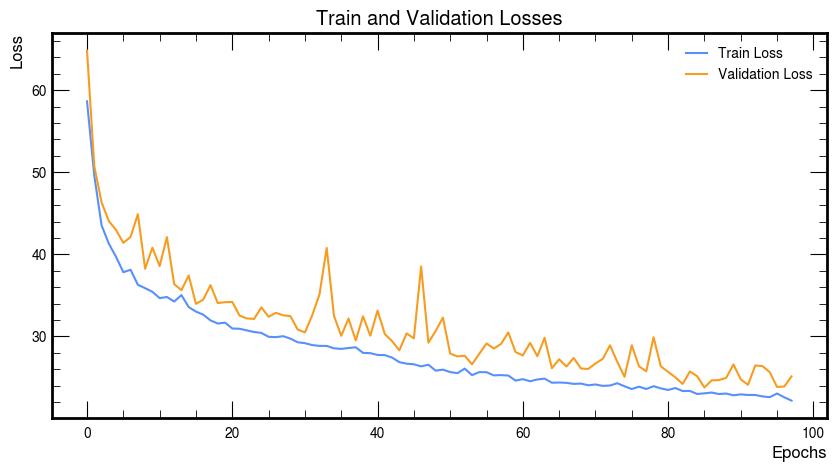

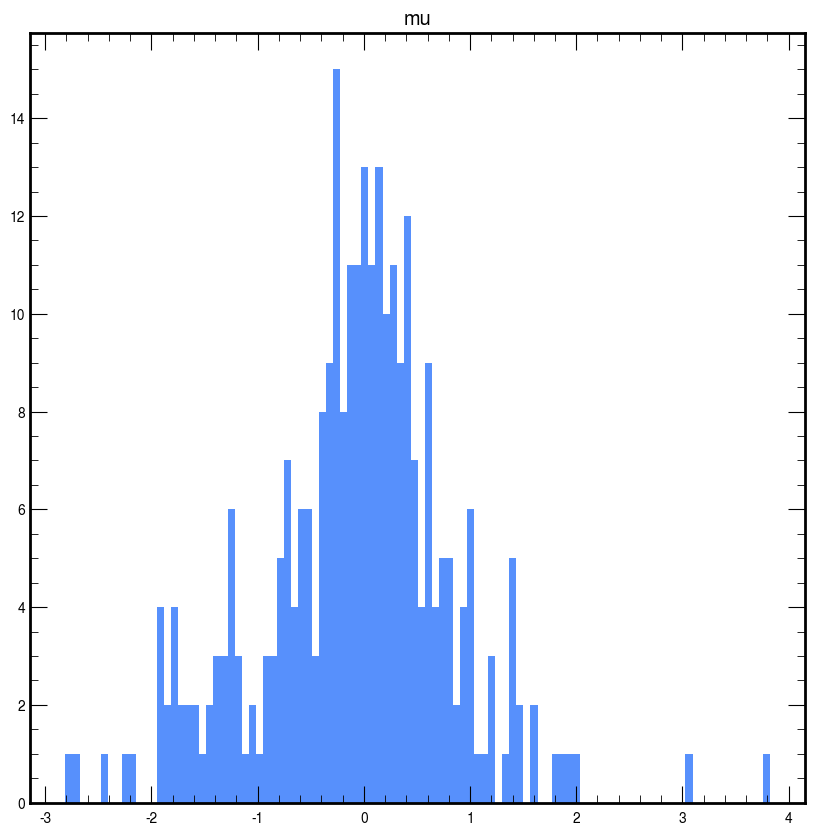

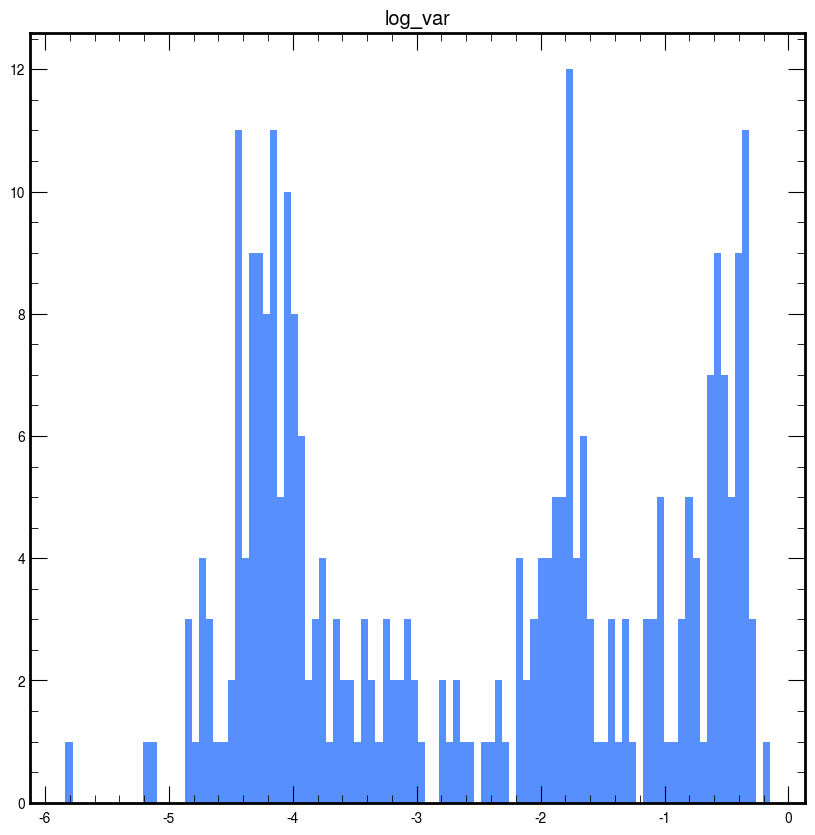

In [331]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses[2:], label='Train Loss')
plt.plot(val_losses[2:], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train and Validation Losses')
plt.legend()
plt.show()

plt.hist(mu.flatten().cpu().numpy(), bins=100)
plt.title('mu')
plt.show()
plt.hist(log_var.flatten().cpu().numpy(), bins=100)
plt.title('log_var')
plt.show()

Amostra do VAE tentando reproduzir o dataset de treino (dados normalizados)

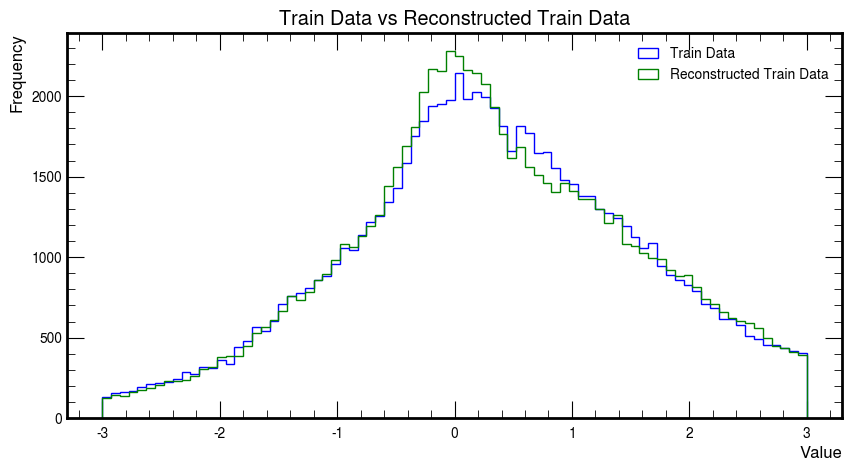

In [332]:
model.eval()
with torch.no_grad():
    recon_train, _, _, _ = model(x_train.float())


plt.figure(figsize=(10, 5))
plt.hist(denormalize(x_train).cpu().numpy().flatten(), bins=80, range=[-3, 3], histtype='step', color='blue', label='Train Data')
plt.hist(denormalize(recon_train).cpu().numpy().flatten(), bins=80, range=[-3, 3], histtype='step', color='green', label='Reconstructed Train Data')
plt.title('Train Data vs Reconstructed Train Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()


Amostra do VAE tentando reproduzir o dataset de teste (dados normalizados)

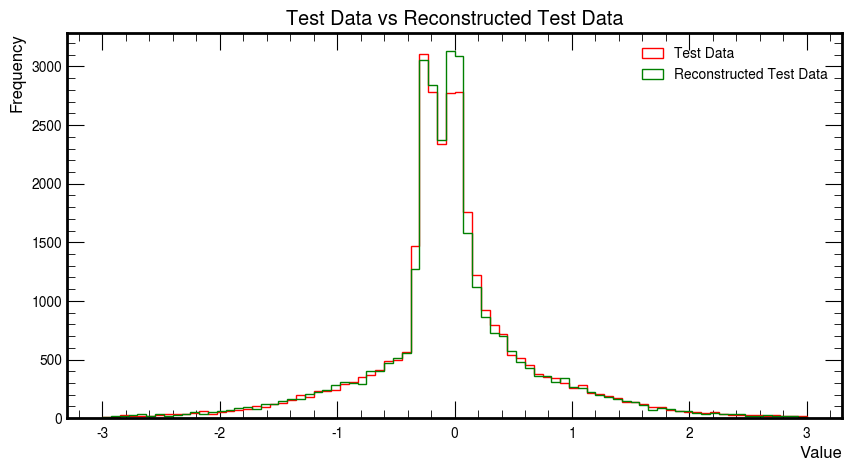

In [333]:
with torch.no_grad():
    recon_test, _, _, _ = model(x_test.float())

plt.figure(figsize=(10, 5))
plt.hist(x_test.cpu().numpy().flatten(), bins=80, range=[-3, 3], histtype='step', color='red', label='Test Data')
plt.hist(recon_test.cpu().numpy().flatten(), bins=80, range=[-3, 3], histtype='step', color='green', label='Reconstructed Test Data')
plt.title('Test Data vs Reconstructed Test Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()


Amostra do VAE tentando gerar novos dados que seguem a distribuição do input (dados normalizados)

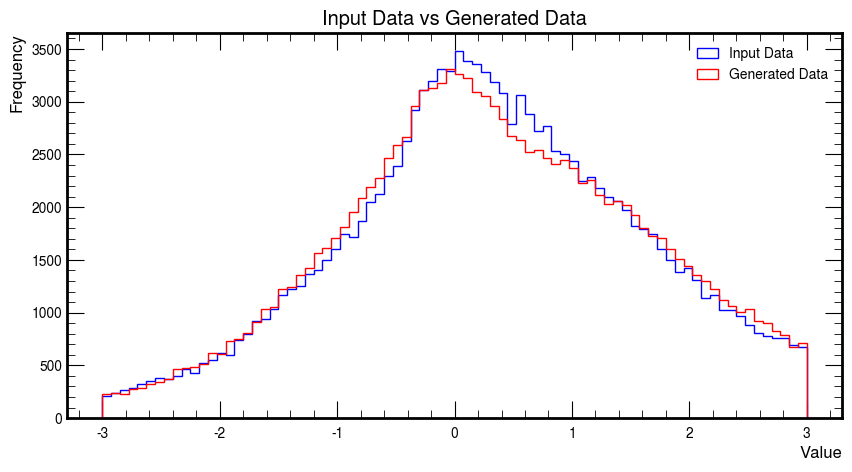

In [334]:
#with torch.no_grad():
    #z = torch.randn(tensor_data.size(0), best_params['latent_dim']).to(device)
    #generated_data = model.decoder(z)

with torch.no_grad():
    
    z = torch.randn(tensor_data.size(0), best_params['latent_dim'], device=device)

    for flow in model.flows:
        z, _ = flow(z)
    generated_data = model.decoder(z)

plt.figure(figsize=(10, 5))
plt.hist(tensor_data_denormalized.cpu().numpy().flatten(), bins=80, range=[-3, 3], histtype='step', color='blue', label='Input Data')
plt.hist(denormalize(generated_data).cpu().numpy().flatten(), bins=80, range=[-3, 3], histtype='step', color='red', label='Generated Data')
plt.title('Input Data vs Generated Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()


In [335]:
import scipy.stats as stats
# Teste de Kolmogorov-Smirnov
train_recon_ks = stats.ks_2samp(x_train.cpu().numpy().flatten(), recon_train.cpu().numpy().flatten())
test_recon_ks = stats.ks_2samp(x_test.cpu().numpy().flatten(), recon_test.cpu().numpy().flatten())
input_generated_ks = stats.ks_2samp(tensor_data.cpu().numpy().flatten(), generated_data.cpu().numpy().flatten())

print(f"KS test for Train vs. Reconstructed Train: statistic={train_recon_ks.statistic}, p-value={train_recon_ks.pvalue}")
print(f"KS test for Test vs. Reconstructed Test: statistic={test_recon_ks.statistic}, p-value={test_recon_ks.pvalue}")
print(f"KS test for Input vs. Generated: statistic={input_generated_ks.statistic}, p-value={input_generated_ks.pvalue}")

KS test for Train vs. Reconstructed Train: statistic=0.015333333333333421, p-value=3.1175068064496065e-10
KS test for Test vs. Reconstructed Test: statistic=0.019874999999999976, p-value=6.38513044739565e-06
KS test for Input vs. Generated: statistic=0.010962499999999986, p-value=8.850016176638754e-09


Abaixo, iremos desnormalizar os dados para gerar plots com a distribuição original, retomando a problemática da distribuição dos momentos tranversais dos píons e dos kaons.

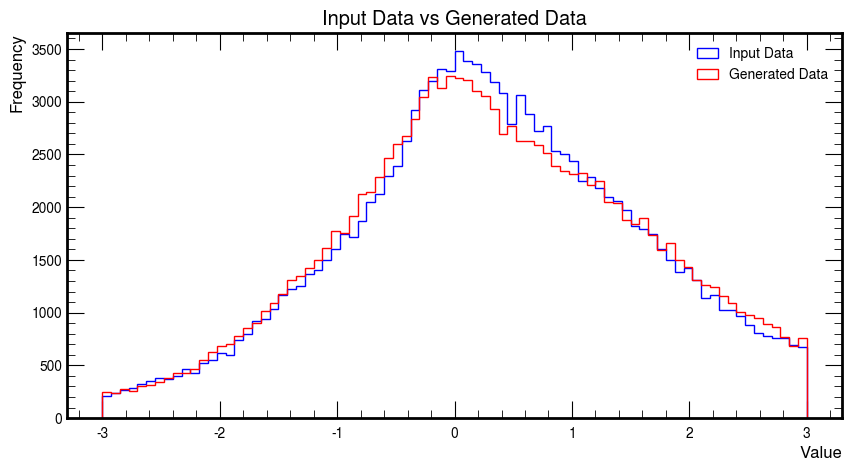

In [336]:
with torch.no_grad():

    z = torch.randn(tensor_data.size(0), best_params['latent_dim'], device=device)

    for flow in model.flows:
        z, _ = flow(z)
    generated_data = model.decoder(z)

plt.figure(figsize=(10, 5))
plt.hist(tensor_data_denormalized.cpu().numpy().flatten(), bins=80, range=[-3, 3], histtype='step', color='blue', label='Input Data')
plt.hist(denormalize(generated_data).cpu().numpy().flatten(), bins=80, range=[-3, 3], histtype='step', color='red', label='Generated Data')
plt.title('Input Data vs Generated Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()

Amostra do VAE tentando reproduzir o dataset de treino (dados desnormalizados)

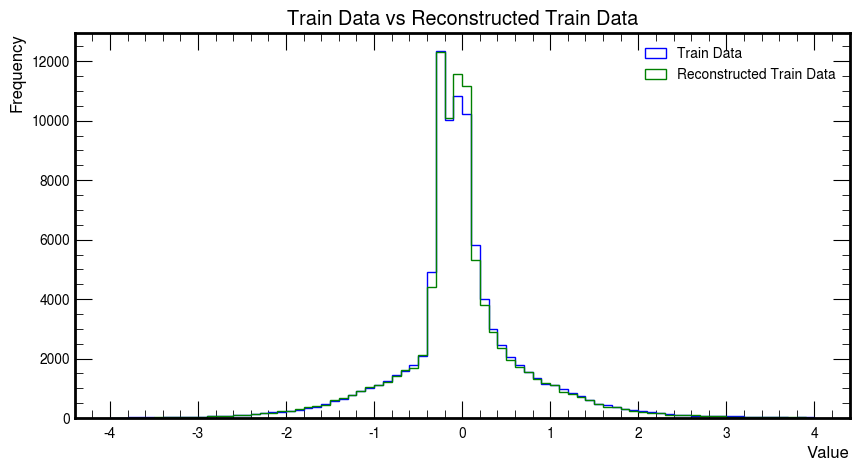

In [337]:
plt.figure(figsize=(10, 5))
plt.hist(x_train.cpu().numpy().flatten(), bins=80, range=[-4, 4], histtype='step', color='blue', label='Train Data')
plt.hist(recon_train.cpu().numpy().flatten(), bins=80, range=[-4, 4], histtype='step', color='green', label='Reconstructed Train Data')
plt.title('Train Data vs Reconstructed Train Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()

Amostra do VAE tentando reproduzir o dataset de teste (dados desnormalizados)

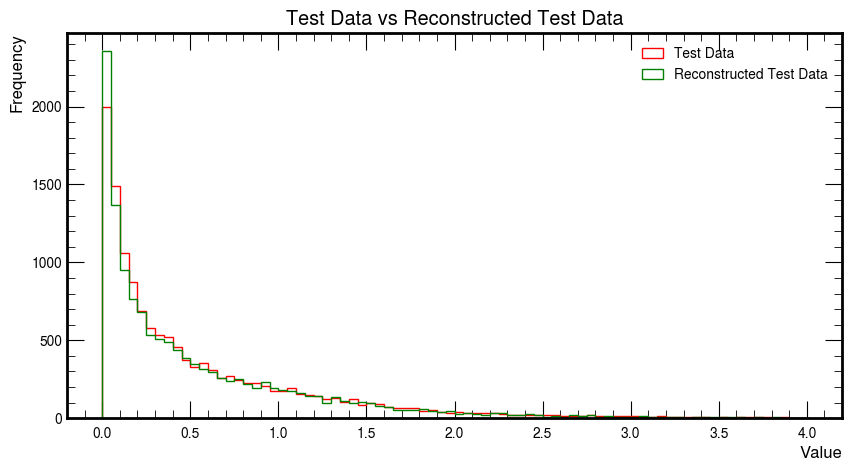

In [338]:
plt.figure(figsize=(10, 5))
plt.hist(x_test.cpu().numpy().flatten(), bins=80, range=[0, 4], histtype='step', color='red', label='Test Data')
plt.hist(recon_test.cpu().numpy().flatten(), bins=80, range=[0, 4], histtype='step', color='green', label='Reconstructed Test Data')
plt.title('Test Data vs Reconstructed Test Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()

Amostra do VAE tentando gerar novos dados que seguem a mesma distribuição do input (dados desnormalizados)

In [339]:
# PLOTS FUNCTION

def subplot_trk(data, generated, trk):
    if trk == "trk1":
        id_list = [0, 2, 4, 6]
        name_list = ["Kaons x component momentum (Px)", "Kaons y component momentum (Py)", "Kaons z component momentum (Pz)", "Kaons energy (E)"]
    if trk == "trk2":
        id_list = [1, 3, 5, 7]
        name_list = ["Pions x component momentum (Px)", "Pions y component momentum (Py)", "Pions z component momentum (Pz)", "Pions energy (E)"]
    if trk == "both":
        data_tensor = torch.zeros([2*data.size()[0], 4])
        gen_tensor = torch.zeros([2*data.size()[0], 4])
        data_tensor[:, 0], gen_tensor[:, 0] = data[:, :2].flatten(), generated[:, :2].flatten()
        data_tensor[:, 1], gen_tensor[:, 1] = data[:, 2:4].flatten(), generated[:, 2:4].flatten()
        data_tensor[:, 2], gen_tensor[:, 2] = data[:, 4:6].flatten(), generated[:, 4:6].flatten()
        data_tensor[:, 3], gen_tensor[:, 3] = data[:, 6:8].flatten(), generated[:, 6:8].flatten()
        data, generated = data_tensor, gen_tensor
        id_list = [0, 1, 2, 3]
        name_list = ["Px1+Px2", "Py1+Py2", "Pz1+Pz2", "E1+E2"]
        
    range_list = [[-5, 5], [-5, 5], [-5, 5], [0, 20]]
    
    plt.figure(figsize=(10,10))
    for i in range(len(id_list)):
        plt.subplot(2, 2, i+1)
        plt.hist(data[:, id_list[i]].numpy().flatten(), bins=80, range=range_list[i], histtype='step', color='blue', label='Input Data')
        plt.hist(generated[:, id_list[i]].numpy().flatten(), bins=80, range=range_list[i], histtype='step', color='red', label='Generated Data')
        plt.title(f'{name_list[i]}')
        plt.xlabel('Value')
        plt.ylabel('Frequency')
        plt.legend()

    return plt.show()

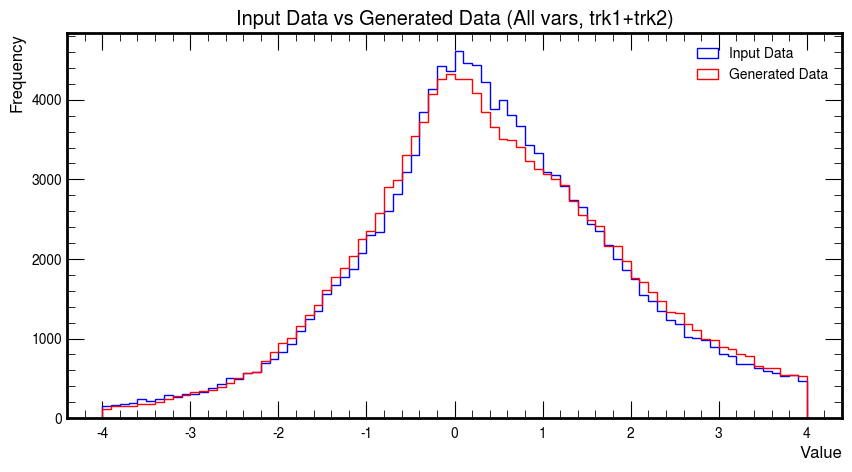

torch.Size([20000, 8])


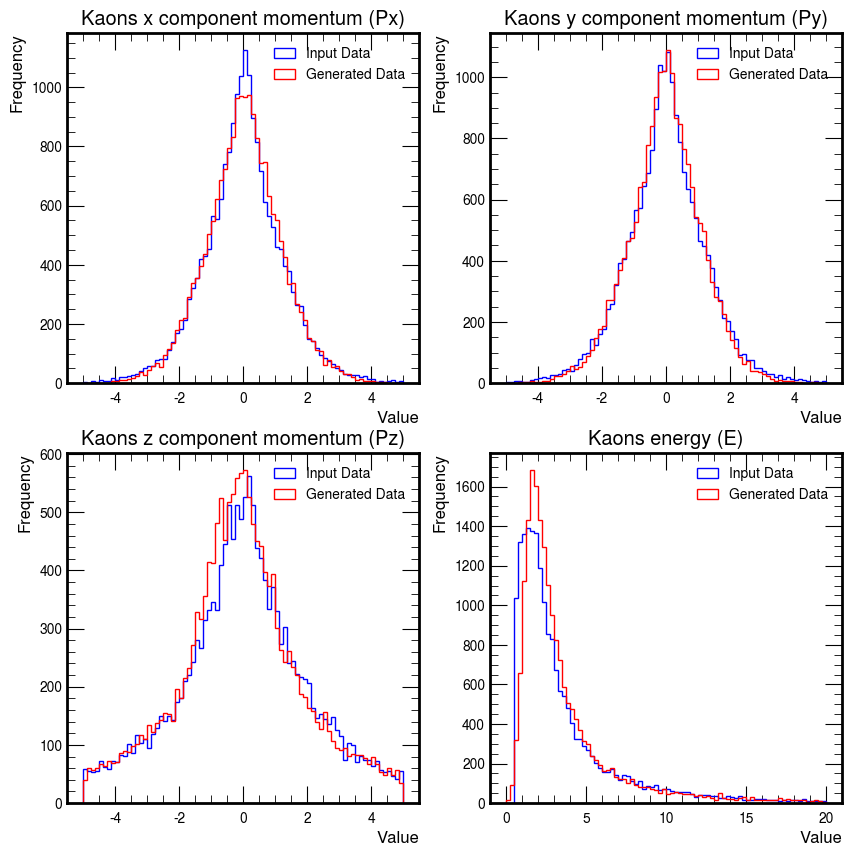

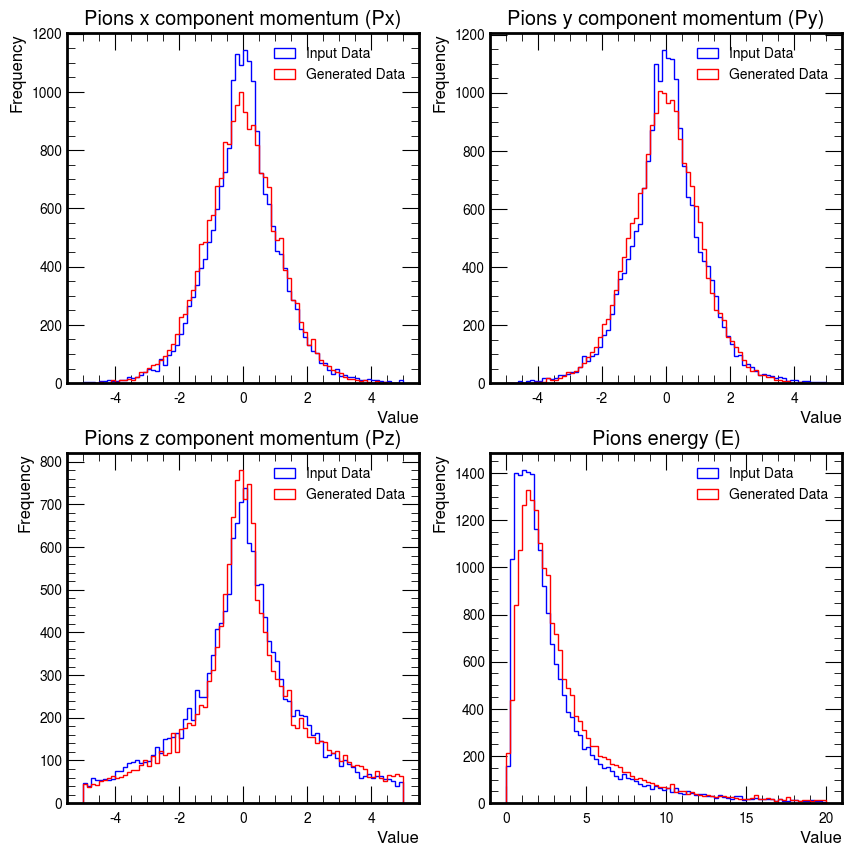

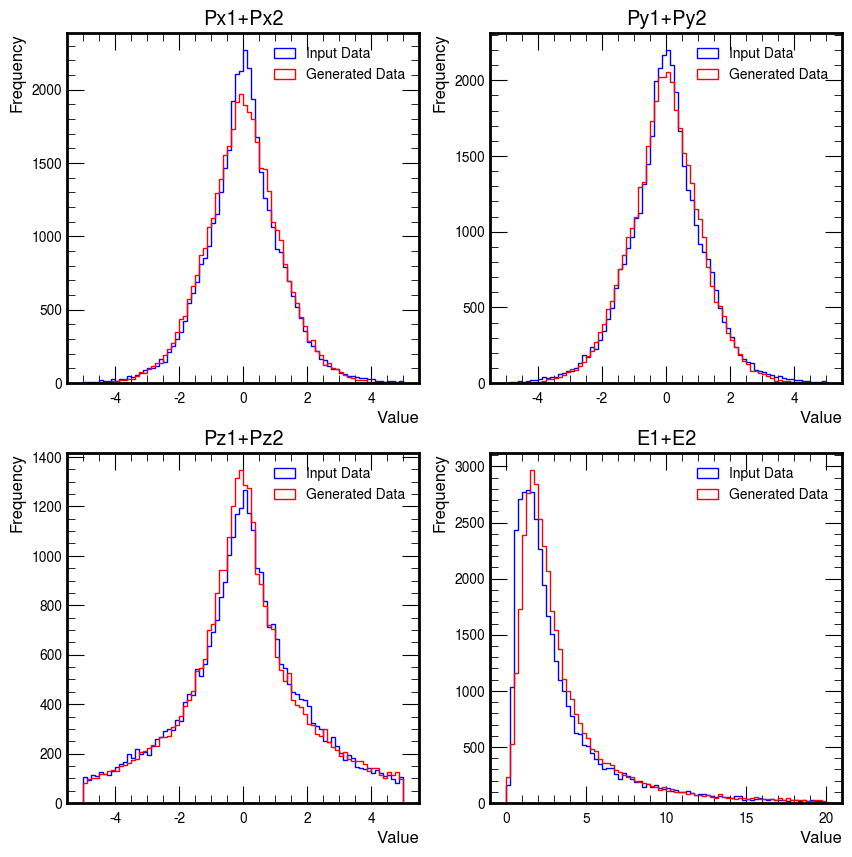

In [340]:
plt.figure(figsize=(10, 5))
plt.hist(tensor_data_denormalized.cpu().flatten(), bins=80, range=[-4, 4], histtype='step', color='blue', label='Input Data')
plt.hist(denormalize(generated_data).cpu().flatten(), bins=80, range=[-4, 4], histtype='step', color='red', label='Generated Data')
plt.title('Input Data vs Generated Data (All vars, trk1+trk2)')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()

print(tensor_data.size())
subplot_trk(tensor_data_denormalized.cpu(), denormalize(generated_data).cpu(), "trk1")
subplot_trk(tensor_data_denormalized.cpu(), denormalize(generated_data).cpu(), "trk2")
subplot_trk(tensor_data_denormalized.cpu(), denormalize(generated_data).cpu(), "both")

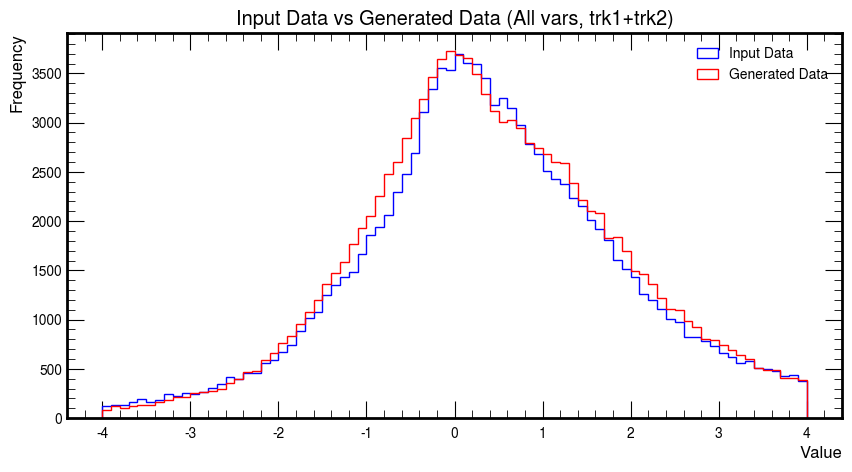

torch.Size([16231, 8])


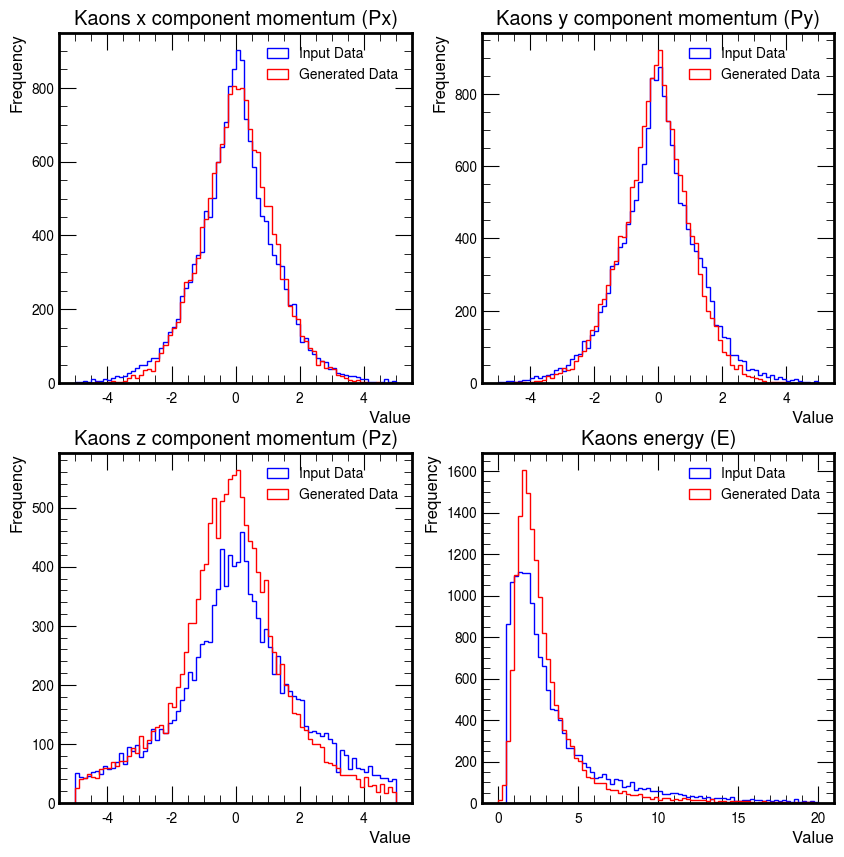

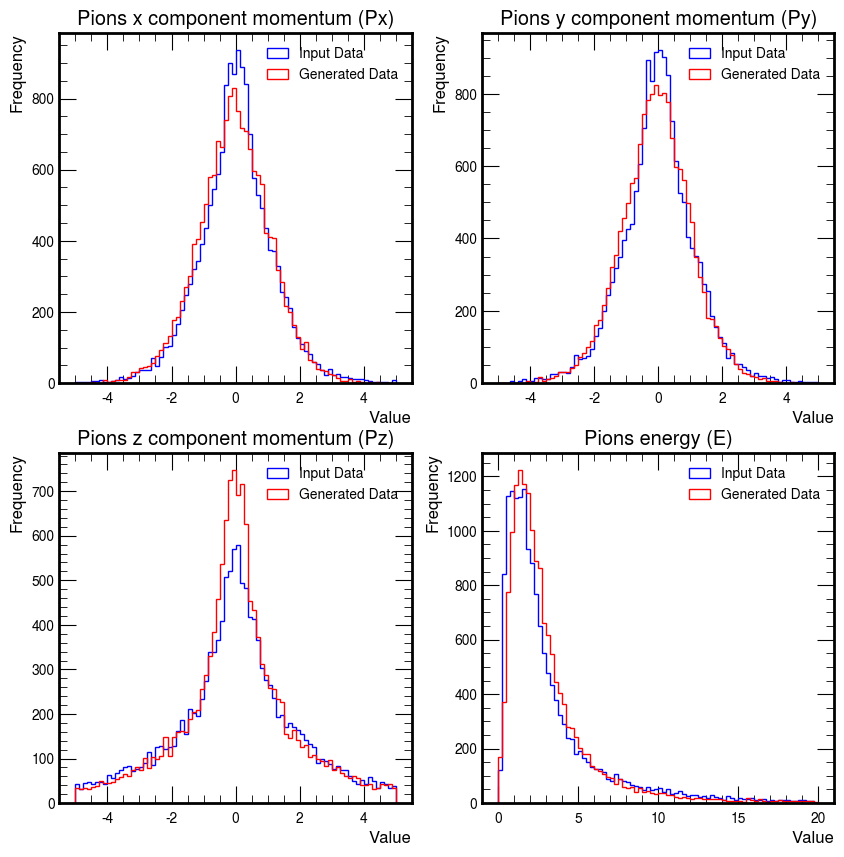

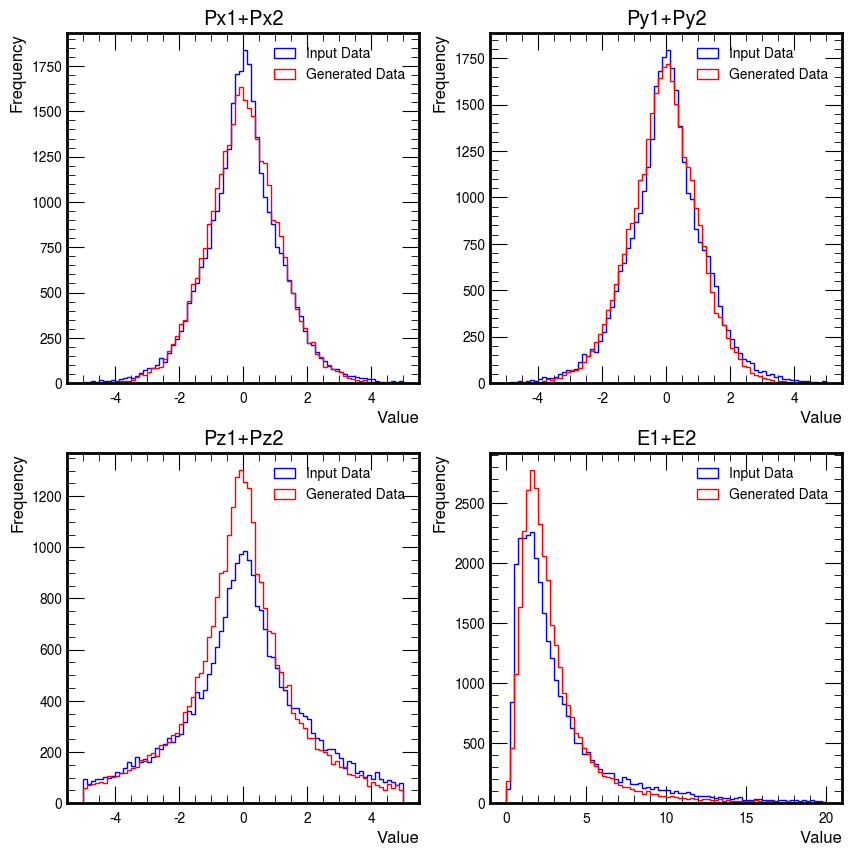

In [341]:
generated_data_denormalized = denormalize(generated_data)

generated_px = generated_data_denormalized[:, 0] + generated_data_denormalized[:, 1]
generated_py = generated_data_denormalized[:, 2] + generated_data_denormalized[:, 3]
generated_pz = generated_data_denormalized[:, 4] + generated_data_denormalized[:, 5]
generated_E = generated_data_denormalized[:, 6] + generated_data_denormalized[:, 7]


mass2 = generated_E**2 - generated_px**2 - generated_py**2 - generated_pz**2
mass_mask = mass2 > 0

energies_mask = ((generated_data_denormalized[:, 6] > 0) & (generated_data_denormalized[:, 7] > 0))
physical_mask = (mass_mask & energies_mask)
filtered_generated_data = generated_data_denormalized[physical_mask]
filtered_tensor_data_denormalized = tensor_data_denormalized[physical_mask]

plt.figure(figsize=(10, 5))
plt.hist(filtered_tensor_data_denormalized.cpu().flatten(), bins=80, range=[-4, 4], histtype='step', color='blue', label='Input Data')
plt.hist(filtered_generated_data.cpu().flatten(), bins=80, range=[-4, 4], histtype='step', color='red', label='Generated Data')
plt.title('Input Data vs Generated Data (All vars, trk1+trk2)')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()

print(filtered_tensor_data_denormalized.size())
subplot_trk(filtered_tensor_data_denormalized.cpu(), filtered_generated_data.cpu(), "trk1")
subplot_trk(filtered_tensor_data_denormalized.cpu(), filtered_generated_data.cpu(), "trk2")
subplot_trk(filtered_tensor_data_denormalized.cpu(), filtered_generated_data.cpu(), "both")

Abaixo, é rodado um teste de Kolmogorov-Smirnov para analisar a proximidade dos dois hitogramas em cada gráfico (apenas para as distribuições desnormalizadas). Uma das métricas de interesse é o p-valor.

P-Valor Significativo: um p-valor abaixo de 0.05 é frequentemente considerado significativo, o que indica que a hipótese nula (de que as distribuições são iguais) pode ser rejeitada.

P-Valor Não Significativo: Um p-valor acima de 0.05 geralmente sugere que não há evidência suficiente para rejeitar a hipótese nula. Valores como 0.10, 0.15, ou mais altos são interpretados como indicando uma falta de diferença significativa entre as distribuições.

P-Valor > 0.05: Indica que não há uma diferença significativa entre as distribuições comparadas. Esse é um bom sinal, sugerindo que as distribuições dos dados gerados ou reconstruídos são semelhantes aos dados reais.

P-Valor > 0.10 ou 0.15: Indica uma forte semelhança entre as distribuições, o que é ótimo.

In [342]:
import scipy.stats as stats
# Teste de Kolmogorov-Smirnov
train_recon_ks = stats.ks_2samp(x_train.cpu().flatten(), recon_train.cpu().flatten())
test_recon_ks = stats.ks_2samp(x_test.cpu().flatten(), recon_test.cpu().flatten())
input_generated_ks = stats.ks_2samp(tensor_data.cpu().flatten(), generated_data.cpu().flatten())

print(f"KS test for Train vs. Reconstructed Train: statistic={train_recon_ks.statistic}, p-value={train_recon_ks.pvalue}")
print(f"KS test for Test vs. Reconstructed Test: statistic={test_recon_ks.statistic}, p-value={test_recon_ks.pvalue}")
print(f"KS test for Input vs. Generated: statistic={input_generated_ks.statistic}, p-value={input_generated_ks.pvalue}")

KS test for Train vs. Reconstructed Train: statistic=0.015333333333333421, p-value=3.1175068064496065e-10
KS test for Test vs. Reconstructed Test: statistic=0.019874999999999976, p-value=6.38513044739565e-06
KS test for Input vs. Generated: statistic=0.010656250000000034, p-value=2.5533576464929787e-08


In [343]:
print(mass_func(generated_data_denormalized).mean())
print(torch.sqrt(torch.clamp(mass_func(generated_data_denormalized).mean(), min=0.0)))  #  1.8648 

tensor(9.6679, device='cuda:0')
tensor(3.1093, device='cuda:0')


In [344]:
wasserstein_distance(tensor_data.cpu().numpy().flatten(), generated_data.cpu().numpy().flatten())

np.float64(0.05943753365709572)

In [345]:
# Comparação correta — test set vs gerado condicionado no test set
input_generated_ks = stats.ks_2samp(
    x_test.cpu().numpy().flatten(),
    generated_data.cpu().numpy().flatten()
)

cols = ['px1','px2','py1','py2','pz1','pz2','E1','E2']
for i, name in enumerate(cols):
    w = wasserstein_distance(
        x_test.cpu().numpy()[:, i],
        generated_data.cpu().numpy()[:, i]
    )
    print(f"  {name}: {w:.4f}")

  px1: 0.0599
  px2: 0.0733
  py1: 0.0532
  py2: 0.0490
  pz1: 0.1265
  pz2: 0.0742
  E1: 0.1352
  E2: 0.0696
